# 🚀 Pipeline de Previsão de Quantidades com LightGBM


Este notebook foi criado para organizar o processo de **treino e previsão** da variável `quantity`
usando o modelo **LightGBM**.  

A pipeline está organizada em funções reutilizáveis para facilitar a aplicação tanto
nos dados de treino quanto em novos arquivos CSV de teste.


In [175]:
import pandas as pd

def agrupar_categoria_treino(df, colunas_para_agrupar, limite_representatividade=1, limite_diferenca_media=0.4):
    mapeamentos = {}

    for coluna in colunas_para_agrupar:
        print(f"Processando a coluna: '{coluna}'...")
        total_linhas = len(df)
        medias_por_categoria = df.groupby(coluna)['quantity'].mean()
        contagens_por_categoria = df[coluna].value_counts()
        representatividade = (contagens_por_categoria / total_linhas) * 100

        categorias_pequenas = representatividade[representatividade < limite_representatividade].index.tolist()

        # Criação do mapeamento
        mapeamento_grupos = {}
        for i in range(len(categorias_pequenas)):
            for j in range(i + 1, len(categorias_pequenas)):
                cat1 = categorias_pequenas[i]
                cat2 = categorias_pequenas[j]
                if abs(medias_por_categoria[cat1] - medias_por_categoria[cat2]) <= limite_diferenca_media:
                    # O novo nome pode ser definido de forma mais robusta, por exemplo, combinando os nomes das categorias
                    # ou usando um prefixo como 'OUTROS_'
                    novo_nome = f"GRUPO_{cat1}_{cat2}"
                    mapeamento_grupos[cat1] = novo_nome
                    mapeamento_grupos[cat2] = novo_nome

        # Aplica o mapeamento no dataframe de treino
        df[coluna] = df[coluna].replace(mapeamento_grupos)

        # Armazena o mapeamento para uso futuro
        mapeamentos[coluna] = mapeamento_grupos

        print(f"Agrupamento concluído para a coluna '{coluna}'.")
        print("-" * 40)

    return df, mapeamentos

def agrupar_categoria_previsao(df, mapeamentos, colunas_para_agrupar):
    for coluna in colunas_para_agrupar:
        if coluna in mapeamentos:
            mapeamento = mapeamentos[coluna]
            df[coluna] = df[coluna].replace(mapeamento)
            print(f"Mapeamento aplicado para a coluna '{coluna}'.")
        else:
            print(f"A coluna '{coluna}' não tem um mapeamento salvo. Não foi realizada nenhuma alteração.")
    return df

In [176]:

# 📅 Função para criar colunas de tempo (mês e semana)
def cria_colunas(df):
    df['month'] = df['reference_date'].dt.month
    df['week_of_year'] = df['transaction_date'].dt.isocalendar().week.astype(int)
    df['week'] = df['week_of_year'] - df.groupby('month')['week_of_year'].transform('min') + 1
    # Remove as colunas permanentemente do DataFrame
    df.drop('week_of_year', axis=1, inplace=True)
    df.drop('reference_date', axis=1, inplace=True)
    df.drop('transaction_date', axis=1, inplace=True)
    return df


In [177]:

# 📊 Função de agrupamento
def agrupamento(df, treino=True):
    colunas_para_agrupar = ['pdv', 'premise', 'categoria_pdv', 'zipcode', 'produto',
                            'categoria', 'label', 'marca', 'week', 'month']

    if treino:
        agregacoes = {
            'quantity': 'sum',
            'gross_value': 'sum',
            'taxes_por_prod': 'mean' # Corrigido para 'mean'
        }
    else:
        agregacoes = {
            'gross_value': 'sum',
            'taxes_por_prod': 'mean' # Corrigido para 'mean'
        }

    df = df.groupby(colunas_para_agrupar).agg(agregacoes).reset_index()
    return df


In [178]:

# 🤖 Função para treinar modelo LightGBM
import lightgbm as lgb
from sklearn.model_selection import train_test_split
import numpy as np

def treinar_lightgbm(df):
    colunas_categ = ['categoria_pdv', 'categoria', 'label', 'marca', 'premise']
    train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)
    X_train = train_df.drop(columns="quantity")
    y_train = train_df["quantity"]
    X_test = test_df.drop(columns="quantity")
    y_test = test_df["quantity"]

    X_train['pdv'] = X_train['pdv'].astype(int)
    X_test['pdv'] = X_test['pdv'].astype(int)
    X_train['produto'] = X_train['produto'].astype(int)
    X_test['produto'] = X_test['produto'].astype(int)

    for col in colunas_categ:
        X_train[col] = X_train[col].astype('category')
        X_test[col] = X_test[col].astype('category')

    model = lgb.LGBMRegressor(
        objective='regression',
        boosting_type='gbdt',
        n_estimators=1000,
        metric='mae',
        verbose=-1
    )

    model.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        eval_metric='mae',
        callbacks=[lgb.early_stopping(stopping_rounds=50)]
    )

    y_pred = model.predict(X_test)
    wmape_test = np.sum(np.abs(y_test - y_pred)) / np.sum(np.abs(y_test))
    print("WMAPE real no teste:", wmape_test)

    return model


In [179]:

# 📈 Função para prever novos dados
def prever_lightgbm(model, df):
    colunas_categ = ['categoria_pdv', 'categoria', 'label', 'marca', 'premise']
    for col in colunas_categ:
        if col in df.columns:
            df[col] = df[col].astype('category')
    preds = model.predict(df.drop(columns="quantity", errors="ignore"))
    return preds


In [ ]:
# 🤖 Função para treinar modelo XGBoost
import xgboost as xgb
from sklearn.model_selection import train_test_split
import numpy as np

def treinar_xgboost(df):
    colunas_categ = ['categoria_pdv', 'categoria', 'label', 'marca', 'premise']
    train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)
    X_train = train_df.drop(columns="quantity")
    y_train = train_df["quantity"]
    X_test = test_df.drop(columns="quantity")
    y_test = test_df["quantity"]

    # Converte colunas numéricas específicas
    X_train['pdv'] = X_train['pdv'].astype(int)
    X_test['pdv'] = X_test['pdv'].astype(int)
    X_train['produto'] = X_train['produto'].astype(int)
    X_test['produto'] = X_test['produto'].astype(int)

    # Converte colunas categóricas para category (XGBoost aceita como "category" a partir da versão 1.6+)
    for col in colunas_categ:
        if col in X_train.columns:
            X_train[col] = X_train[col].astype('category')
            X_test[col] = X_test[col].astype('category')

    # Modelo XGBoost
    model = xgb.XGBRegressor(
        objective='reg:squarederror',
        n_estimators=1000,
        learning_rate=0.05,
        max_depth=8,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        tree_method="hist"  # usa histograma para treinar mais rápido
    )

    # Treinamento com early stopping
    model.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        eval_metric='mae',
        early_stopping_rounds=50,
        verbose=False
    )

    # Predição e cálculo do WMAPE
    y_pred = model.predict(X_test)
    wmape_test = np.sum(np.abs(y_test - y_pred)) / np.sum(np.abs(y_test))
    print("WMAPE real no teste:", wmape_test)

    return model


# 📈 Função para prever novos dados com XGBoost
def prever_xgboost(model, df):
    colunas_categ = ['categoria_pdv', 'categoria', 'label', 'marca', 'premise']
    for col in colunas_categ:
        if col in df.columns:
            df[col] = df[col].astype('category')
    preds = model.predict(df.drop(columns="quantity", errors="ignore"))
    return preds

##Funções para Mapeamento de Dados

In [180]:
import pandas as pd

def criar_mapeamentos_taxa_e_crescimento(df_treino: pd.DataFrame):
    # TRATAMENTO DE VALORES INF E NaN
    df_treino.replace([float('inf'), -float('inf')], 0, inplace=True) # Substitui inf por 0
    df_treino.fillna(0, inplace=True) # Preenche NaN com 0, se necessário

    mapeamento_taxes = df_treino.groupby('produto')['taxes_por_prod'].mean().reset_index()

    # Certifique-se de que o DataFrame df_mensal já está agrupado por 'month'
    df_mensal = df_treino.groupby('month').agg({'gross_value': 'sum'}).reset_index()

    # Verifique se há valores para janeiro e dezembro
    if 1 in df_mensal['month'].values and 12 in df_mensal['month'].values:
        valor_jan_22 = df_mensal[df_mensal['month'] == 1]['gross_value'].iloc[0]
        valor_dez_22 = df_mensal[df_mensal['month'] == 12]['gross_value'].iloc[0]

        # Adicione uma verificação para evitar a divisão por zero
        if valor_jan_22 != 0:
            taxa_crescimento_total = (valor_dez_22 / valor_jan_22) - 1

            # --- Ajuste principal aqui ---
            # Usa a fórmula de crescimento composto para encontrar a taxa mensal média
            # O crescimento total ocorreu em 11 períodos de transição (de jan a dez)
            taxa_mensal_media = (1 + taxa_crescimento_total) ** (1/11) - 1

        else:
            taxa_crescimento_total = 0
            taxa_mensal_media = 0
    else:
        taxa_crescimento_total = 0
        taxa_mensal_media = 0

    multiplicador_crescimento = 1 + taxa_mensal_media
    return mapeamento_taxes, multiplicador_crescimento

##Função para Criar o DataFrame de Previsão

In [181]:
import pandas as pd

def criar_df_previsao(df_treino: pd.DataFrame, mapeamento_taxes: pd.DataFrame, multiplicador_crescimento: float, ano: int, mes: int):
    """
    Cria o DataFrame de previsão para janeiro de 2023.

    Args:
        df_treino (pd.DataFrame): O DataFrame de treinamento (usado para obter a base de jan/22).
        mapeamento_taxes (pd.DataFrame): DataFrame com a média de taxes_por_prod por produto.
        multiplicador_crescimento (float): O multiplicador para aplicar ao gross_value.
        ano (int): O ano de previsão.
        mes (int): O mês de previsão.

    Returns:
        pd.DataFrame: O DataFrame de previsão pronto para ser usado no modelo.
    """
    # Filtra os dados de janeiro de 2022 para usar como base
    df_janeiro_2022 = df_treino[df_treino['month'] == 1].copy()

    # Cria o DataFrame de previsão
    df_previsao = df_janeiro_2022.copy()

    # Aplica o multiplicador de crescimento ao gross_value
    df_previsao['gross_value'] = df_previsao['gross_value'] * multiplicador_crescimento

    # Agora, remove a coluna 'taxes_por_prod' original do df_previsao antes do merge
    df_previsao = df_previsao.drop(columns=['taxes_por_prod'])

    # Adiciona a taxes_por_prod estimada com base no mapeamento
    df_previsao = pd.merge(df_previsao, mapeamento_taxes, on='produto', how='left')

    # Renomeia e limpa outras colunas
    colunas_para_dropar = ['quantity', 'taxes', 'net_value', 'gross_profit', 'discount']
    df_previsao = df_previsao.drop(columns=colunas_para_dropar, errors='ignore')

    return df_previsao

In [224]:
import pandas as pd

def ajustar_e_salvar_csv(df: pd.DataFrame, nome_arquivo: str = 'resultados_ajustados.csv'):
    """
    Ajusta o DataFrame para conter apenas as colunas renomeadas e
    salva o resultado em um arquivo CSV.

    Args:
        df (pd.DataFrame): O DataFrame a ser ajustado.
        nome_arquivo (str): O nome do arquivo CSV de saída.
    """
    try:
        # 1. Seleciona as colunas com os nomes originais
        df_ajustado = df[['week', 'pdv', 'produto', 'quantity']].copy()

        # 2. Renomeia as colunas para os nomes corretos
        df_ajustado = df_ajustado.rename(columns={'week': 'semana', 'quantity': 'quantidade'})

        # 3. Arredondanr 'quantidade'
        df_ajustado['quantidade'] = df_ajustado['quantidade'].round(0).astype(int)

        # 3. Salva o DataFrame ajustado em um arquivo CSV
        df_ajustado.to_csv(nome_arquivo, index=False, sep=';')

        print(f"DataFrame ajustado salvo com sucesso em '{nome_arquivo}'.")

    except KeyError as e:
        print(f"Erro: O DataFrame não contém as colunas necessárias. Verifique se 'week', 'pdv', 'produto' ou 'quantity' estão presentes. Erro: {e}")
    except Exception as e:
        print(f"Ocorreu um erro: {e}")


#1 Leitura dos dados

In [183]:
!pip install fastparquet python-snappy
!pip install ydata_profiling

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ydata_profiling import ProfileReport
import seaborn as sns

In [184]:
# Transações
!gdown 1q_aJDrarK-wHYpWcz_nST0GADmCQl9aV -O transacoes.parquet
df_transacoes = pd.read_parquet("transacoes.parquet", engine="fastparquet")
print(df_transacoes)

# Produtos
!gdown 1vf9mzIUlZ6KNrsBHs4rlgNDkm-JwOtQT -O produtos.parquet
df_produtos = pd.read_parquet("produtos.parquet", engine="fastparquet")
print(df_produtos)

# PDVs
!gdown 1dqCNyVVq9BRcd3DE83dgVG1Vf1CvJlTX -O pdvs.parquet
df_pdvs = pd.read_parquet("pdvs.parquet", engine="fastparquet")
print(df_pdvs)

Downloading...
From (original): https://drive.google.com/uc?id=1q_aJDrarK-wHYpWcz_nST0GADmCQl9aV
From (redirected): https://drive.google.com/uc?id=1q_aJDrarK-wHYpWcz_nST0GADmCQl9aV&confirm=t&uuid=fea2a959-b7b9-43e6-a116-55a86b2b3dda
To: /content/transacoes.parquet
100% 139M/139M [00:00<00:00, 199MB/s]
           internal_store_id  internal_product_id distributor_id  \
0        7384367747233276219   328903483604537190              9   
1        3536908514005606262  5418855670645487653              5   
2        3138231730993449825  1087005562675741887              6   
3        3681167389484217654  1401422983880045188              5   
4        7762413312337359369  6614994347738381720              4   
...                      ...                  ...            ...   
6560693  1439579822593789678  2523145330235258825              4   
6560694  2357589266242432199  3148628429396585683              4   
6560695  7245187752757348055  6668439675743950745              4   
6560696  89526093

In [185]:
bdtech_hackaton1 = pd.read_parquet('pdvs.parquet', engine='fastparquet')
print(bdtech_hackaton1)

                       pdv      premise     categoria_pdv  zipcode
0      2204965430669363375   On Premise      Mexican Rest    30741
1      5211957289528622910   On Premise       Hotel/Motel    80011
2      9024493554530757353  Off Premise       Convenience    80751
3      8659197371382902429   On Premise        Restaurant    80439
4      1400854873763881130   On Premise        Restaurant    30093
...                    ...          ...               ...      ...
14414  5047149578012031122  Off Premise    Package/Liquor    81501
14415  8352177618955815208  Off Premise    Package/Liquor    80219
14416  7754182004766664314   On Premise     Special Event    81004
14417  9044929558186581877   On Premise  Other On Premise    81226
14418  8795399024619655297   On Premise               Bar    80205

[14419 rows x 4 columns]


In [186]:
bdtech_hackaton2 = pd.read_parquet('produtos.parquet', engine='fastparquet')
print(bdtech_hackaton2)

                  produto          categoria  \
0     2282334733936076502  Distilled Spirits   
1     6091840953834683482  Distilled Spirits   
2     1968645851245092408  Distilled Spirits   
3      994706710729219179              Draft   
4     9209550539540384349        Non-Alcohol   
...                   ...                ...   
7087  2552936302329139135  Distilled Spirits   
7088  5175418594860080319              Draft   
7089  2514391530951310058  Distilled Spirits   
7090  9183313499769355186               Wine   
7091  3567332082927026738               Wine   

                                              descricao              tipos  \
0                           JOSEPH CARTRON CAFÉ LIQUEUR  Distilled Spirits   
1                  SPRINGBANK 18 YEAR SINGLE MALT 700ML  Distilled Spirits   
2                     J BRANDT TRIPLE SEC 12/750ML 30PF  Distilled Spirits   
3                      REFORMATION CASHMERE IPA 1/4 KEG              Draft   
4                               H

In [187]:
bdtech_hackaton3 = pd.read_parquet('transacoes.parquet', engine = 'fastparquet')
print(bdtech_hackaton3)

           internal_store_id  internal_product_id distributor_id  \
0        7384367747233276219   328903483604537190              9   
1        3536908514005606262  5418855670645487653              5   
2        3138231730993449825  1087005562675741887              6   
3        3681167389484217654  1401422983880045188              5   
4        7762413312337359369  6614994347738381720              4   
...                      ...                  ...            ...   
6560693  1439579822593789678  2523145330235258825              4   
6560694  2357589266242432199  3148628429396585683              4   
6560695  7245187752757348055  6668439675743950745              4   
6560696  8952609383990245450  3894706280449257667              5   
6560697   815150310325179165  3479075165556992938              4   

        transaction_date reference_date  quantity  gross_value    net_value  \
0             2022-07-13     2022-07-01       1.0    38.125000    37.890625   
1             2022-03-21 

#2 Tratamento de dados

In [188]:
merged_df = pd.merge(bdtech_hackaton1, bdtech_hackaton3, left_on = 'pdv', right_on = 'internal_store_id', how = 'inner').drop('internal_store_id', axis=1)
merged_df = pd.merge(merged_df, bdtech_hackaton2, left_on = 'internal_product_id', right_on = 'produto', how = 'inner').drop('internal_product_id', axis=1)
display(merged_df.head())

,pdv,premise,categoria_pdv,zipcode,distributor_id,transaction_date,reference_date,quantity,gross_value,net_value,...,discount,taxes,produto,categoria,descricao,tipos,label,subcategoria,marca,fabricante
0,2204965430669363375,On Premise,Mexican Rest,30741,4,2022-05-10,2022-05-01,1.0,19.990000,19.990000,...,1.0,0.000000,8654618855511723434,Non-Alcohol,LANGERS ORANGE JUICE 100% 12/32 NR,Non Alcohol,Discontinued,Juice & Tea,Langers Orange,Langers Juice Company
1,2204965430669363375,On Premise,Mexican Rest,30741,4,2022-08-01,2022-08-01,12.0,52.799999,38.158596,...,7.2,14.641404,5168467358507505407,Distilled Spirits,PEDRO MORALES TRIPLE SEC 1 LTR,Distilled Spirits,Core,Liqueurs & Cordials,Pedro Morales Triple Sec,Sazerac ABA
2,2204965430669363375,On Premise,Mexican Rest,30741,4,2022-08-01,2022-08-01,2.0,47.200001,42.640484,...,0.0,4.559516,3262679882836704514,Package,BUD LIGHT 2/12/12 LN,Package,Core,Lager,Bud Light,AB Anheuser Busch Inc
3,2204965430669363375,On Premise,Mexican Rest,30741,4,2022-07-08,2022-07-01,1.0,23.500000,22.584913,...,2.8,0.915087,14523659809755688,Distilled Spirits,BLUE NECTAR SILVER 750ML,Distilled Spirits,Core,Tequila / Mezcal,Blue Nectar Silver,Blue Nectar
4,2204965430669363375,On Premise,Mexican Rest,30741,4,2022-10-24,2022-10-01,1.0,25.000000,25.000000,...,0.0,0.000000,2888002190098573554,Non-Alcohol,JARRITOS FRUIT PUNCH 24/524ML PET BOTTLE,Hispanic,Core,Soda,Jarritos Fruit Punch,Novamex


In [189]:
#Para eter uma noção das colunas
merged_df.info()
merged_df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6515116 entries, 0 to 6515115
Data columns (total 21 columns):
 #   Column            Dtype         
---  ------            -----         
 0   pdv               object        
 1   premise           object        
 2   categoria_pdv     object        
 3   zipcode           int32         
 4   distributor_id    object        
 5   transaction_date  datetime64[ns]
 6   reference_date    datetime64[ns]
 7   quantity          float64       
 8   gross_value       float64       
 9   net_value         float64       
 10  gross_profit      float64       
 11  discount          float64       
 12  taxes             float64       
 13  produto           object        
 14  categoria         object        
 15  descricao         object        
 16  tipos             object        
 17  label             object        
 18  subcategoria      object        
 19  marca             object        
 20  fabricante        object        
dtypes: datet

(6515116, 21)

##Tratamento de valores nulos

In [190]:
#Verificando valores nulos
merged_df.isnull().sum()

,0
pdv,0
premise,0
categoria_pdv,0
zipcode,0
distributor_id,0
transaction_date,0
reference_date,0
quantity,0
gross_value,0
net_value,0


Pimeiro para entender o que faremos come esses valores nulos vamos entender as correalações para entender se queremos ou não usar essas colunas

##Valores negativos e possíveis inconsistências


In [191]:
list_var = ['quantity','gross_value','net_value','gross_profit','discount','taxes']

contagem_negativos = (merged_df[list_var] < 0).sum()

print(contagem_negativos)

quantity         70041
gross_value      73037
net_value        73648
gross_profit    146750
discount         25392
taxes            63600
dtype: int64


Vamos verificar se a relação gross_value - taxes = net_value (aproximadamente) se satisfaz, como parece se satisfazer pela observação do dataframe

In [192]:
# Note que com a hipótese se satisfazendo então diferenca == 0
diferenca = (merged_df['net_value'] + merged_df['taxes']) - merged_df['gross_value']
#Por lidar com float estabeleceremos um lambda = 0.01 para concluir que
#diferenca == 0
condicao_aproximadamente_iguais = diferenca.abs() <= 0.01
#contagem de casos que foram satisfeitos
contagem_iguais = condicao_aproximadamente_iguais.sum()
#Verificação de casos onde isso não se satisfaz
condicao_diferentes = diferenca.abs() > 0.01
#contagem de casos que não foram satisfeitos
contagem_diferentes = condicao_diferentes.sum()
total = contagem_iguais + contagem_diferentes
print(contagem_iguais/total, contagem_diferentes/total)

1.0 0.0


Isso se satisfaz e parece não haver inconsistência nos dados relacionados a isso. E sobre os valores negativos eles não necessariamente querem dizer algum erro devido aos vários casos possíveis de devolução, acréscimo de imposto e etc...

Note que é sim possível que haja erros de digitação, por exemplo, mas como não podemos provar iremos desconsiderar

## Relatorio

In [193]:
'''# Gere o relatório de perfil
profile = ProfileReport(merged_df, title="Relatório de Análise Exploratória de Dados")

# Salve o relatório em um arquivo HTML
profile.to_file("relatorio_eda.html")'''

'# Gere o relatório de perfil\nprofile = ProfileReport(merged_df, title="Relatório de Análise Exploratória de Dados")\n\n# Salve o relatório em um arquivo HTML\nprofile.to_file("relatorio_eda.html")'

##Matriz de Correlação para drop de colunas

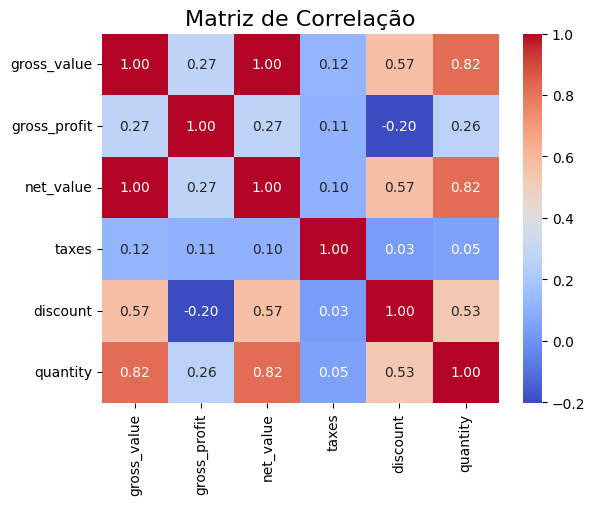

In [194]:
df_matriz = merged_df[['gross_value','gross_profit','net_value','taxes','discount','quantity']]

matriz_correlacao = df_matriz.corr()
sns.heatmap(matriz_correlacao, annot=True, cmap='coolwarm', fmt=".2f")

# Adiciona um título ao gráfico
plt.title('Matriz de Correlação', fontsize=16)

#Exibe o gráfico
plt.show()

A correlação completa de gross_value e net_value já era espreada dado que net_value = gross_value - taxes e, por isso, vamos retirar net_value do data frame. Também por motivos de correlação iremos tirar 'gross_profit'

Note que há um problema de valores faltantes quando realizar a previsão para jan/2023: Ao aplicar a previsão para jan/2023 teremos um problema para criar as colunas para nossos valores continuos dado que também teriamos que ter esses valores para a previsão, mas como não temos vamos retirar as colunas ['net_value', 'gross_profit', 'discount'].

'discount' retiramos, pois discount esta muito sueito a estrtégia do pdv.

In [195]:
#Retirando gross_value
merged_df = merged_df.drop('net_value', axis=1)
#Retirando gross_profit
merged_df = merged_df.drop('gross_profit', axis=1)
#Retirando discount
merged_df = merged_df.drop('discount', axis=1)

Para lidar com 'taxes'vamos transformar em 'tax_por_prod' e assumir que vai se manter igual. Dado que a taxa por produto não costuma mudar.

In [196]:
#criando a coluna 'preco_por_prod'
merged_df['taxes_por_prod'] = merged_df['taxes'] / merged_df['quantity']
#Retirando 'taxes'
merged_df = merged_df.drop('taxes', axis=1)

Vamos também retirar descricao, por não agregar informação no df

In [197]:
merged_df= merged_df.drop('descricao', axis = 1)

E tirar subcategoria e tipos pela alta correlação com categoria

In [198]:
merged_df = merged_df.drop('subcategoria', axis =1)
merged_df = merged_df.drop('tipos', axis =1)

Pela alta correlação entre zipcode e distridutor_id iremos retirar distributor_id para reduzir dimensionalidade. Dado que distributor_id é str e zipcode é float, mas também por outros motivos da natureza do zipcode, dado que números próximos representam lugares próximos e isso fará mais sentido para a árvore de decisão final

In [199]:
merged_df = merged_df.drop('distributor_id', axis =1)

In [200]:
##Precisa colocar dados de correlação que justifiquem tirar fabricante





merged_df = merged_df.drop('fabricante', axis =1)

In [201]:
display(merged_df)

,pdv,premise,categoria_pdv,zipcode,transaction_date,reference_date,quantity,gross_value,produto,categoria,label,marca,taxes_por_prod
0,2204965430669363375,On Premise,Mexican Rest,30741,2022-05-10,2022-05-01,1.000000,19.990000,8654618855511723434,Non-Alcohol,Discontinued,Langers Orange,0.000000
1,2204965430669363375,On Premise,Mexican Rest,30741,2022-08-01,2022-08-01,12.000000,52.799999,5168467358507505407,Distilled Spirits,Core,Pedro Morales Triple Sec,1.220117
2,2204965430669363375,On Premise,Mexican Rest,30741,2022-08-01,2022-08-01,2.000000,47.200001,3262679882836704514,Package,Core,Bud Light,2.279758
3,2204965430669363375,On Premise,Mexican Rest,30741,2022-07-08,2022-07-01,1.000000,23.500000,14523659809755688,Distilled Spirits,Core,Blue Nectar Silver,0.915087
4,2204965430669363375,On Premise,Mexican Rest,30741,2022-10-24,2022-10-01,1.000000,25.000000,2888002190098573554,Non-Alcohol,Core,Jarritos Fruit Punch,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6515111,8795399024619655297,On Premise,Bar,80205,2022-09-11,2022-09-01,11.000004,274.760103,2000299989413890957,Distilled Spirits,Allocated,Eagle Rare Single Barrel Kentucky Straight Bou...,0.000000
6515112,8795399024619655297,On Premise,Bar,80205,2022-09-11,2022-09-01,1.000002,25.500051,6182078584966538293,Distilled Spirits,None,Gammel Dansk Bitter Liqueur,0.000000
6515113,8795399024619655297,On Premise,Bar,80205,2022-09-11,2022-09-01,1.999992,51.979794,5800966932260176140,Distilled Spirits,None,Romana Sambuca Liquore Classico,0.000000
6515114,8795399024619655297,On Premise,Bar,80205,2022-09-11,2022-09-01,3.000000,18.929993,813787524868611759,Distilled Spirits,None,Regan's Orange Bitters No.6,0.000000


##Análise e tratamento de outliers

/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:127: RuntimeWarning: invalid value encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)


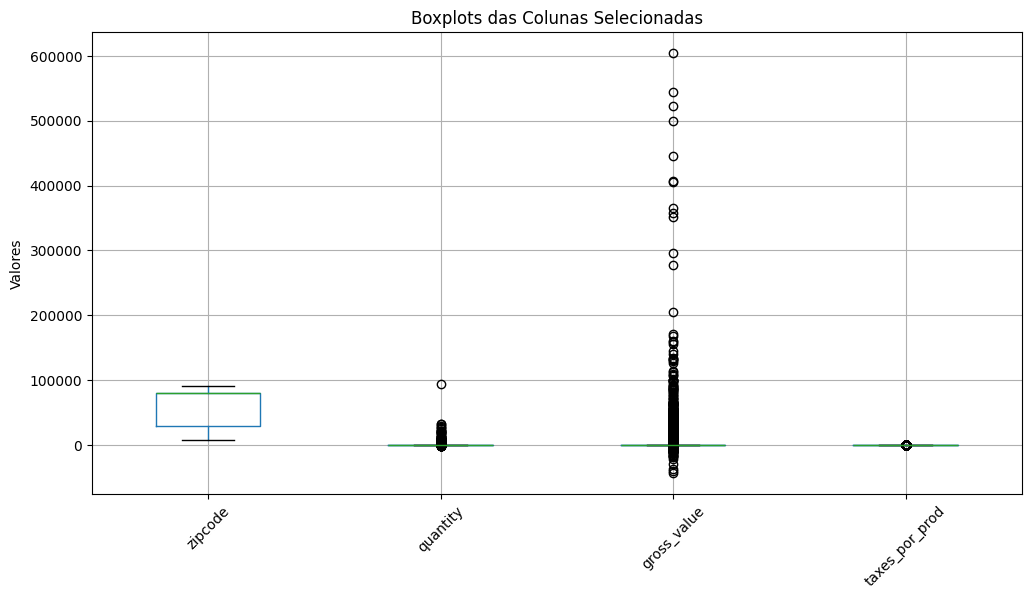

In [202]:
colunas = [
    'pdv',
    'zipcode',
    'quantity',
    'gross_value',
    'taxes_por_prod'
]

# Cria uma única figura com o boxplot para as colunas especificadas.
merged_df[colunas].boxplot(figsize=(12, 6), rot=45)
plt.title('Boxplots das Colunas Selecionadas')
plt.ylabel('Valores')
plt.show()

Pelos gráficos parece haver muito outlier, mas vamos avaliar quanto representa esses outliers

In [203]:
def calcular_outliers(df):
    """
    Calcula e retorna a porcentagem de outliers para cada coluna numérica.
    """
    outliers_porcentagem = {}

    for coluna in df.select_dtypes(include=['number']).columns:
        # Pula colunas com poucos dados para evitar erros de cálculo
        if len(df[coluna]) < 4:
            continue

        Q1 = df[coluna].quantile(0.25)
        Q3 = df[coluna].quantile(0.75)
        IQR = Q3 - Q1

        # Define os limites para os outliers
        limite_inferior = Q1 - 1.5 * IQR
        limite_superior = Q3 + 1.5 * IQR

        # Conta o número de outliers
        total_outliers = df[(df[coluna] < limite_inferior) | (df[coluna] > limite_superior)].shape[0]

        # Calcula a porcentagem
        porcentagem = (total_outliers / len(df[coluna])) * 100
        outliers_porcentagem[coluna] = porcentagem

    return outliers_porcentagem

# Chama a função e exibe o resultado
porcentagens = calcular_outliers(merged_df)
print("Porcentagem de outliers por coluna:")
print(porcentagens)

Porcentagem de outliers por coluna:
{'zipcode': 0.0, 'quantity': 12.722904703461918, 'gross_value': 11.119740615516285, 'taxes_por_prod': 0.9009049109793287}


Apesar dos resultados, ainda não faremos anda com eles. Dado que usaremos um modelo de árvore não precisaremos e é até melhor não mexer nos outliers.

##Mapeando features para usar na previsão

##Representatividade dos valores nas features categóricas

Análise para a coluna: "premise"

Representatividade e Média de Quantidade por Categoria:


,premise,representatividade_%,media_quantidade
0,Off Premise,89.387173,7.933117
1,On Premise,10.612827,9.973330


--------------------------------------------------


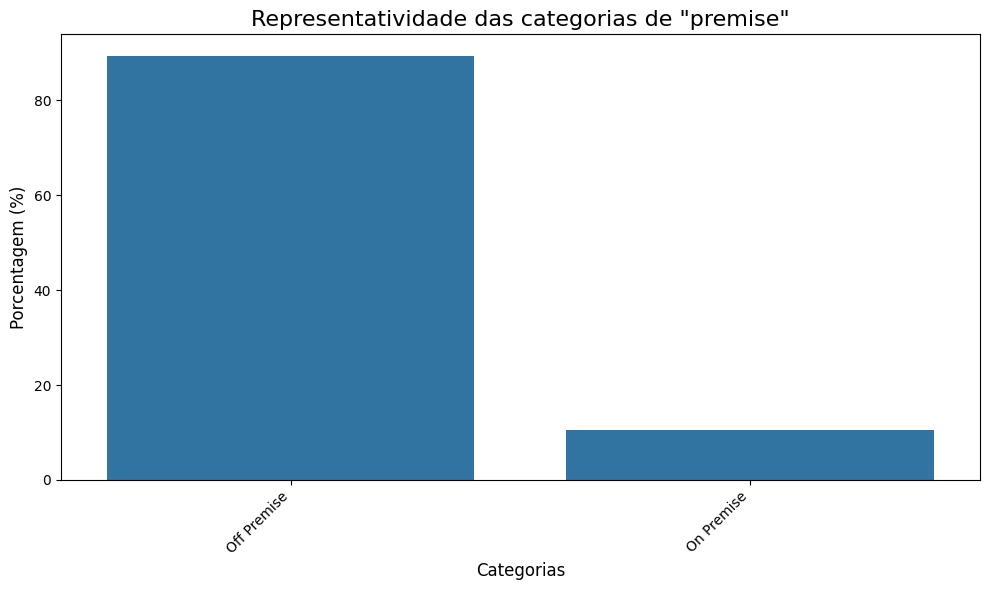

--------------------------------------------------
Análise para a coluna: "categoria_pdv"

Representatividade e Média de Quantidade por Categoria:


,categoria_pdv,representatividade_%,media_quantidade
0,Convenience,32.637638,2.975111
1,Package/Liquor,30.950746,16.745233
2,Grocery,19.585868,2.988311
3,Super Center,5.615019,3.333578
4,Restaurant,4.019284,9.574845
5,Bar,2.956862,9.621489
6,Mexican Rest,0.670932,17.397876
7,Hotel/Motel,0.319672,7.254103
8,Golf - Public,0.304016,6.351658
9,Drug,0.294070,3.342060


--------------------------------------------------


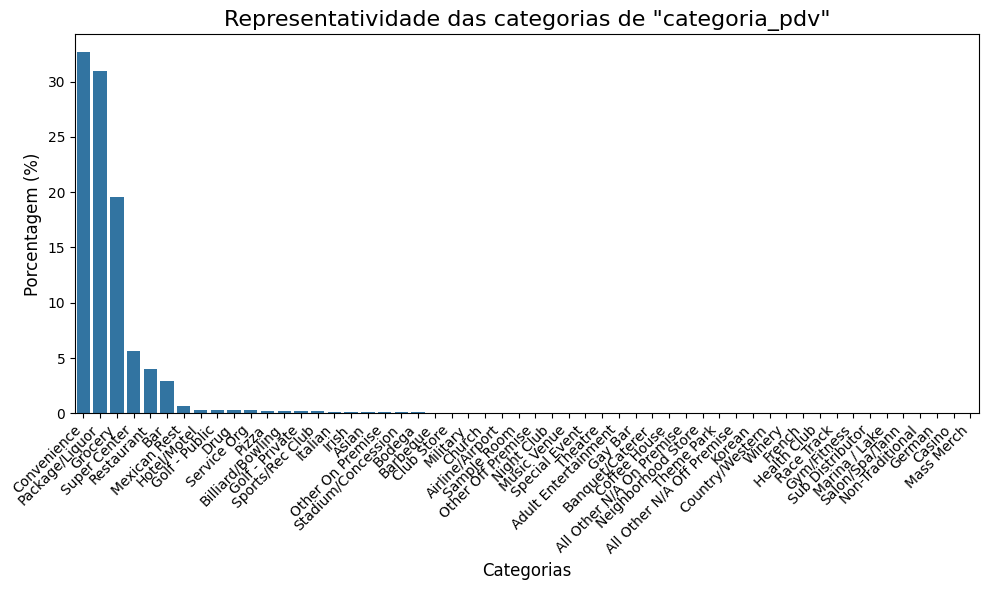

--------------------------------------------------
Análise para a coluna: "categoria"

Representatividade e Média de Quantidade por Categoria:


,categoria,representatividade_%,media_quantidade
0,Package,70.574584,3.719187
1,Non-Alcohol,14.639156,2.013953
2,Distilled Spirits,9.221463,52.115469
3,Draft,2.909987,1.478272
4,Wine,1.855255,19.273574
5,ABA Spirits,0.792987,2.962685
6,Tobacco,0.006569,1.843224


--------------------------------------------------


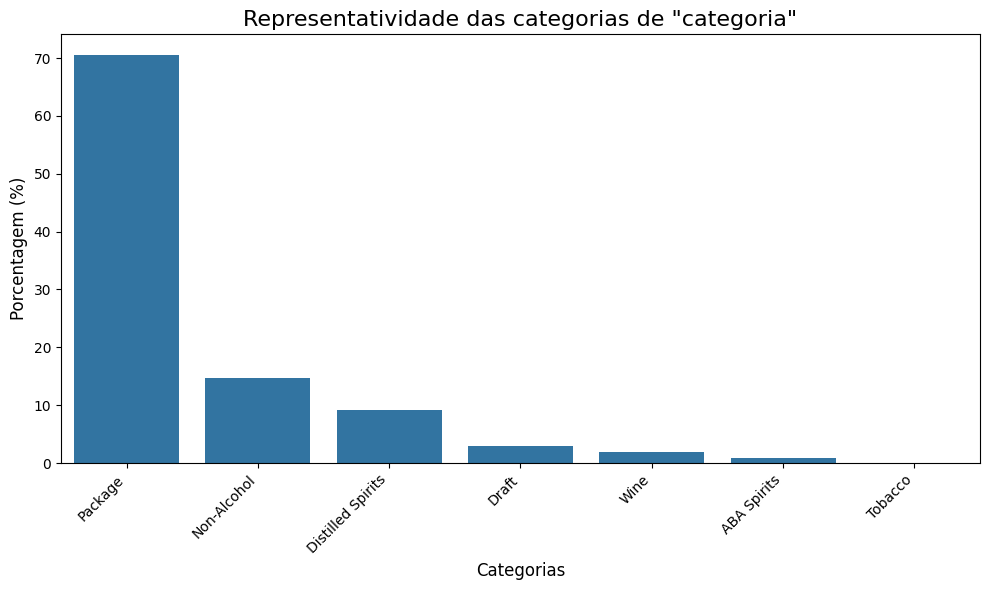

--------------------------------------------------
Análise para a coluna: "label"

Representatividade e Média de Quantidade por Categoria:


,label,representatividade_%,media_quantidade
0,Core,80.373964,3.511727
1,Discontinued,9.541902,4.639594
2,None,7.953135,NaN
3,Allocated,0.872801,36.059008
4,In&Out,0.788750,2.850531
5,Winter Seasonal,0.171969,3.793764
6,Fall Seasonal,0.082976,2.748566
7,Close Out,0.081656,10.594525
8,Specialty,0.071557,5.720077
9,Private Label,0.038357,75.956383


--------------------------------------------------


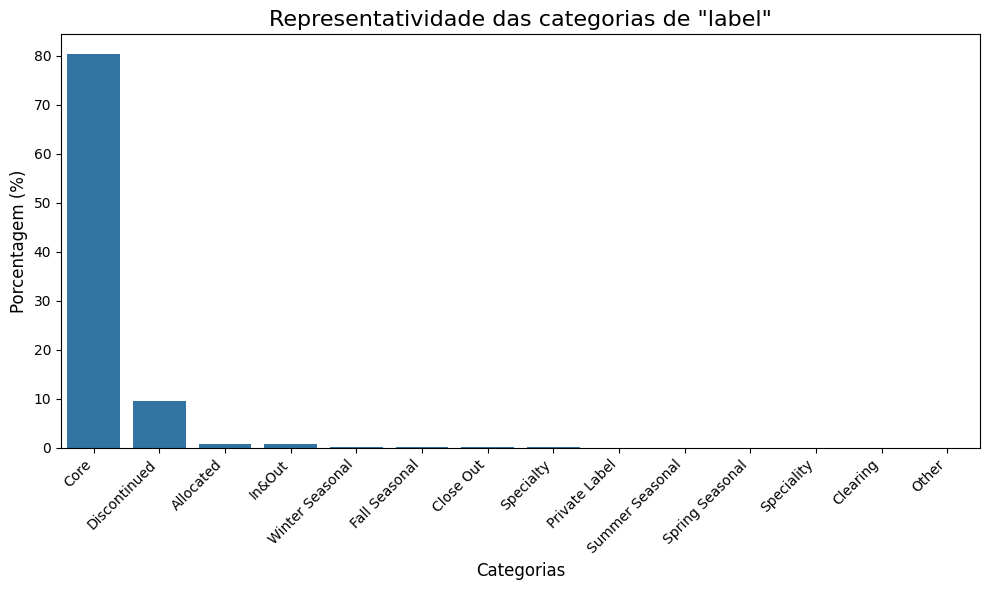

--------------------------------------------------
Análise para a coluna: "marca"

Representatividade e Média de Quantidade por Categoria:


,marca,representatividade_%,media_quantidade
0,Bud Light,13.240317,6.282033
1,Michelob Ultra,9.362381,4.554454
2,Budweiser,8.384901,4.292815
3,Natural Light,2.648287,4.719816
4,Bud Ice,2.279008,3.838772
...,...,...,...
4204,Southern Brewing Company Pilsen Gold Pilsner,0.000015,1.000000
4205,Southern Brewing Company Stout of The Border M...,0.000015,1.000000
4206,Wild Leap Espresso Martini Cocktail - WBS,0.000015,1.000000
4207,Southern Brewing Company Stone Cold IPA,0.000015,1.000000


--------------------------------------------------


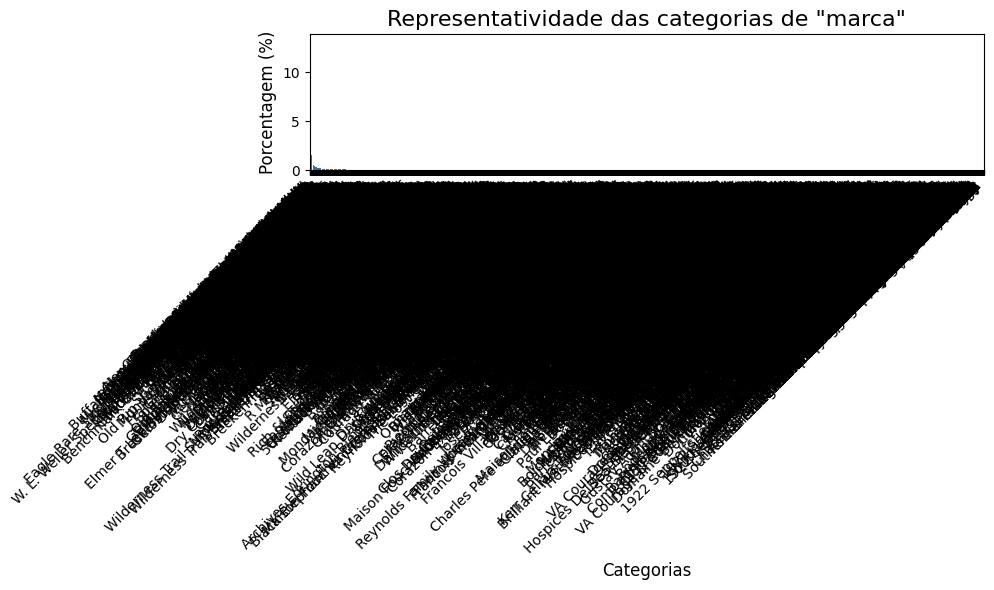

--------------------------------------------------


In [204]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

colunas = [
    'premise',
    'categoria_pdv',
    'categoria',
    'label',
    'marca'
]

for i in colunas:
    print(f'Análise para a coluna: "{i}"')

    # Passo 1: Calcular a representatividade das categorias
    representatividade = merged_df[i].value_counts(normalize=True, dropna =False).reset_index()
    representatividade.columns = [i, 'representatividade_%']
    representatividade['representatividade_%'] = representatividade['representatividade_%'] * 100

    # Passo 2: Calcular a média da quantidade para cada categoria
    media_quantidades = merged_df.groupby(i)['quantity'].mean().reset_index()
    media_quantidades.columns = [i, 'media_quantidade']

    # Passo 3: Juntar os dois DataFrames
    df_analise = pd.merge(representatividade, media_quantidades, on=i, how='left')

    # Passo 4: Exibir o DataFrame consolidado
    print('\nRepresentatividade e Média de Quantidade por Categoria:')
    display(df_analise)

    print('-' * 50) # Adiciona uma linha divisória para melhor visualização

    # O código para o gráfico pode ser mantido ou ajustado
    # para usar o novo DataFrame 'df_analise'

    # Criando o gráfico com seaborn (usando o df_analise para consistência)
    plt.figure(figsize=(10, 6))
    sns.barplot(x=df_analise[i], y=df_analise['representatividade_%'])
    plt.title(f'Representatividade das categorias de "{i}"', fontsize=16)
    plt.xlabel('Categorias', fontsize=12)
    plt.ylabel('Porcentagem (%)', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    print('-' * 50)

##Alterando a base de dados

In [205]:
colunas_para_agrupar = ['premise', 'categoria_pdv', 'categoria', 'label', 'marca']

merged_df, mapeamento = agrupar_categoria_treino(
    merged_df,
    colunas_para_agrupar=colunas_para_agrupar,
    limite_representatividade=1,
    limite_diferenca_media=0.4
)

Processando a coluna: 'premise'...
Agrupamento concluído para a coluna 'premise'.
----------------------------------------
Processando a coluna: 'categoria_pdv'...
Agrupamento concluído para a coluna 'categoria_pdv'.
----------------------------------------
Processando a coluna: 'categoria'...
Agrupamento concluído para a coluna 'categoria'.
----------------------------------------
Processando a coluna: 'label'...
Agrupamento concluído para a coluna 'label'.
----------------------------------------
Processando a coluna: 'marca'...
Agrupamento concluído para a coluna 'marca'.
----------------------------------------


###Criando colunas para capturar sazonalidade por semana

In [206]:
merged_df = cria_colunas(merged_df)

###Agrupando os dados por semana e mês

In [207]:
display(merged_df)

,pdv,premise,categoria_pdv,zipcode,quantity,gross_value,produto,categoria,label,marca,taxes_por_prod,month,week
0,2204965430669363375,On Premise,Mexican Rest,30741,1.000000,19.990000,8654618855511723434,Non-Alcohol,Discontinued,GRUPO_Langers Orange_Joseph Cartron Banane,0.000000,5,3
1,2204965430669363375,On Premise,Mexican Rest,30741,12.000000,52.799999,5168467358507505407,Distilled Spirits,Core,GRUPO_Pedro Morales Triple Sec_Rocca Tesorina ...,1.220117,8,1
2,2204965430669363375,On Premise,Mexican Rest,30741,2.000000,47.200001,3262679882836704514,Package,Core,Bud Light,2.279758,8,1
3,2204965430669363375,On Premise,Mexican Rest,30741,1.000000,23.500000,14523659809755688,Distilled Spirits,Core,GRUPO_Blue Nectar Silver_Ron Izalco 18 Yr Priv...,0.915087,7,2
4,2204965430669363375,On Premise,Mexican Rest,30741,1.000000,25.000000,2888002190098573554,Non-Alcohol,Core,GRUPO_Jarritos Fruit Punch_Chateau Bernard Magrez,0.000000,10,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6515111,8795399024619655297,On Premise,Bar,80205,11.000004,274.760103,2000299989413890957,Distilled Spirits,Allocated,GRUPO_Eagle Rare Single Barrel Kentucky Straig...,0.000000,9,2
6515112,8795399024619655297,On Premise,Bar,80205,1.000002,25.500051,6182078584966538293,Distilled Spirits,None,GRUPO_Gammel Dansk Bitter Liqueur_Iron Hill Be...,0.000000,9,2
6515113,8795399024619655297,On Premise,Bar,80205,1.999992,51.979794,5800966932260176140,Distilled Spirits,None,GRUPO_Romana Sambuca Liquore Classico_Jaspi Negre,0.000000,9,2
6515114,8795399024619655297,On Premise,Bar,80205,3.000000,18.929993,813787524868611759,Distilled Spirits,None,GRUPO_Regan's Orange Bitters No.6_Lovo Blossom...,0.000000,9,2


In [226]:
mapeamento_taxes, multiplicador_crescimento = criar_mapeamentos_taxa_e_crescimento(merged_df)
df_previsao = criar_df_previsao(merged_df, mapeamento_taxes, multiplicador_crescimento,2023,1)
df_previsao_xg = criar_df_previsao(merged_df, mapeamento_taxes, multiplicador_crescimento,2023,1)

In [209]:
merged_df = agrupamento(merged_df)

In [210]:
display(merged_df)

,pdv,premise,categoria_pdv,zipcode,produto,categoria,label,marca,week,month,quantity,gross_value,taxes_por_prod
0,1000237487041964405,On Premise,GRUPO_Winery_Gym/Fitness,30175,1837429607327399565,Package,Core,GRUPO_Fire Maker Perfect Match IPA_Southern Br...,2,2,1.0,35.200001,2.279758
1,1000237487041964405,On Premise,GRUPO_Winery_Gym/Fitness,30175,1837429607327399565,Package,Core,GRUPO_Fire Maker Perfect Match IPA_Southern Br...,3,2,2.0,70.400002,2.279758
2,1000237487041964405,On Premise,GRUPO_Winery_Gym/Fitness,30175,1837429607327399565,Package,Core,GRUPO_Fire Maker Perfect Match IPA_Southern Br...,3,7,2.0,76.800003,2.279758
3,1000237487041964405,On Premise,GRUPO_Winery_Gym/Fitness,30175,1837429607327399565,Package,Core,GRUPO_Fire Maker Perfect Match IPA_Southern Br...,3,11,2.0,76.800003,2.279758
4,1000237487041964405,On Premise,GRUPO_Winery_Gym/Fitness,30175,1837429607327399565,Package,Core,GRUPO_Fire Maker Perfect Match IPA_Southern Br...,4,6,2.0,76.800003,2.279758
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6233911,997907800111849739,Off Premise,Package/Liquor,80205,997545005038320324,Package,Core,GRUPO_TX Ranch Water Lime_Southern Brewing Com...,2,3,1.0,30.000000,0.180000
6233912,997907800111849739,Off Premise,Package/Liquor,80205,997545005038320324,Package,Core,GRUPO_TX Ranch Water Lime_Southern Brewing Com...,3,7,1.0,30.000000,0.180000
6233913,997907800111849739,Off Premise,Package/Liquor,80205,997545005038320324,Package,Core,GRUPO_TX Ranch Water Lime_Southern Brewing Com...,4,3,1.0,30.000000,0.180000
6233914,997907800111849739,Off Premise,Package/Liquor,80205,997545005038320324,Package,Core,GRUPO_TX Ranch Water Lime_Southern Brewing Com...,4,8,1.0,30.000000,0.180000


#Treinamento do modelo

In [211]:
model = treinar_lightgbm(merged_df)
model_xg = treinar_xgboost(merged_df)

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[820]	valid_0's l1: 2.20496
WMAPE real no teste: 0.2564806135975381


#Treinamento para janeiro

In [212]:
display(df_previsao)

,pdv,premise,categoria_pdv,zipcode,gross_value,produto,categoria,label,marca,month,week,ano,mes,taxes_por_prod
0,2204965430669363375,On Premise,Mexican Rest,30741,413.784350,1915930522577773480,Draft,Core,Michelob Ultra,1,4,2023,1,5.927532
1,2204965430669363375,On Premise,Mexican Rest,30741,551.712467,1915930522577773480,Draft,Core,Michelob Ultra,1,1,2023,1,5.927532
2,2204965430669363375,On Premise,Mexican Rest,30741,275.856233,1938760505411922162,Draft,Core,Bud Light,1,4,2023,1,3.308463
3,2204965430669363375,On Premise,Mexican Rest,30741,19.666557,8654618855511723434,Non-Alcohol,Discontinued,GRUPO_Langers Orange_Joseph Cartron Banane,1,4,2023,1,0.000000
4,2204965430669363375,On Premise,Mexican Rest,30741,19.666557,5202453704661408849,Non-Alcohol,Core,GRUPO_Langers Pineapple_Chateau Bernard Magrez,1,1,2023,1,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
381096,8352177618955815208,Off Premise,Package/Liquor,80219,31.833600,1117037298141643903,Package,Core,GRUPO_Estrella Jalisco_Belle Grove Extra Dry S...,1,4,2023,1,0.413342
381097,8352177618955815208,Off Premise,Package/Liquor,80219,157.463563,7029448080469668619,Package,Core,Bud Light,1,1,2023,1,0.237513
381098,8352177618955815208,Off Premise,Package/Liquor,80219,28.319841,1288112997726060694,Package,Core,Budweiser,1,4,2023,1,0.693165
381099,8352177618955815208,Off Premise,Package/Liquor,80219,264.869177,637448570435263100,Package,Core,Bud Ice,1,1,2023,1,1.251027


In [213]:
df_previsao['pdv'] = df_previsao['pdv'].astype(int)
df_previsao_xg['pdv'] = df_previsao_xg['pdv'].astype(int)
df_previsao['produto'] = df_previsao['produto'].astype(int)
df_previsao_xg['produto'] = df_previsao_xg['produto'].astype(int)
df_previsao = agrupamento(df_previsao, False)
df_previsao_xg = agrupamento(df_previsao_xg, False)
# Convertendo a 'pdv' de string para int
preds = prever_lightgbm(model, df_previsao)
preds_xg = prever_xgboost(model_xg, df_previsao_xg)

Erro: O DataFrame não contém as colunas 'pdv', 'produto' ou 'quantity'.


In [215]:
df_previsao['quantity'] = preds
df_previsao_xg['quantity'] = preds_xg

In [225]:
ajustar_e_salvar_csv(df_previsao,'resultados_ajustados_lightgbm.csv')
ajustar_e_salvar_csv(df_previsao_xg,'resultados_ajustados_xgboost.csv')

DataFrame ajustado salvo com sucesso em 'resultados_ajustados(3).csv'.
